# Forecast Using the Toto Family

TimeCopilot ships a single `Toto` class that transparently supports both Toto 1.0 (sample-based) and Toto 2.0 (quantile-knot based) foundation models from Datadog. The model family is detected automatically from the checkpoint, so you only need to pass the right `repo_id`.

In this example we compare Toto 1.0 (151M parameters) against the two smallest Toto 2.0 checkpoints, `Datadog/Toto-2.0-4m` (4M parameters) and `Datadog/Toto-2.0-22m` (22M parameters), together with the classical baselines `Prophet`, `AutoARIMA`, and `SeasonalNaive`.

## Import libraries

In [ ]:
import pandas as pd

from timecopilot import TimeCopilotForecaster

## Load the dataset 

The DataFrame must include at least the following columns:
- unique_id: Unique identifier for each time series (string)
- ds: Date column (datetime format)
- y: Target variable for forecasting (float format)

The pandas frequency will be inferred from the ds column, if not provided.
If the seasonality is not provided, it will be inferred based on the frequency. 
If the horizon is not set, it will default to 2 times the inferred seasonality.

In [2]:
df = pd.read_csv(
    "https://timecopilot.s3.amazonaws.com/public/data/events_pageviews.csv",
    parse_dates=["ds"],
)
df.head()

,unique_id,ds,y
0,Oktoberfest,2020-01-31,25376
1,Oktoberfest,2020-02-29,28470
2,Oktoberfest,2020-03-31,23816
3,Oktoberfest,2020-04-30,46186
4,Oktoberfest,2020-05-31,31213


## Plot the data

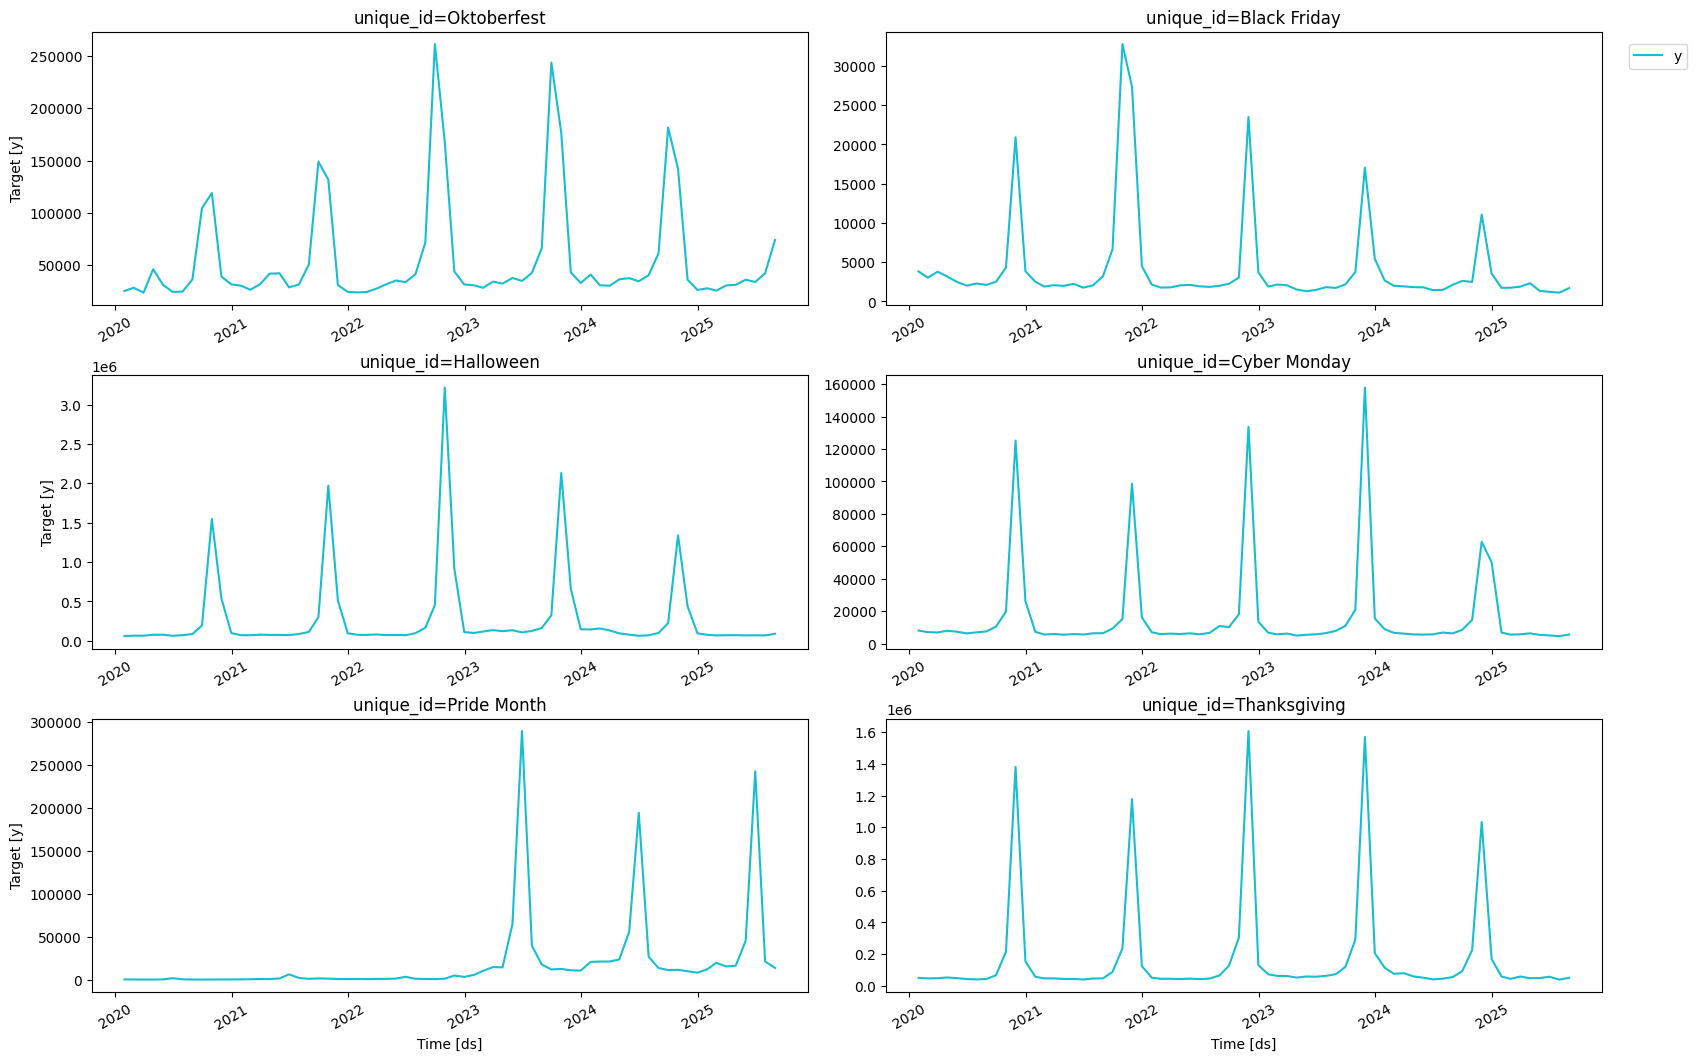

In [3]:
TimeCopilotForecaster.plot(df)

## Import the models

In [ ]:
from timecopilot.models.foundation.toto import Toto
from timecopilot.models.prophet import Prophet
from timecopilot.models.stats import AutoARIMA, SeasonalNaive

## Create a TimeCopilotForecaster

We compare Toto 1.0 (`Datadog/Toto-Open-Base-1.0`, 151M parameters) with the two smallest Toto 2.0 checkpoints, `Datadog/Toto-2.0-4m` (4M parameters) and `Datadog/Toto-2.0-22m` (22M parameters), against `Prophet`, `AutoARIMA`, and `SeasonalNaive`. Each model gets a distinct `alias` so its forecasts are easy to identify.

In [5]:
models = [
    Toto(repo_id="Datadog/Toto-Open-Base-1.0", alias="Toto-1-151M"),
    Toto(repo_id="Datadog/Toto-2.0-4m", alias="Toto-2-4M"),
    Toto(repo_id="Datadog/Toto-2.0-22m", alias="Toto-2-22M"),
    Prophet(),
    AutoARIMA(),
    SeasonalNaive(),
]

tcf = TimeCopilotForecaster(models=models)

## Generate forecast 

You can optionally specify the following parameters:
- freq: The frequency of your data (e.g., 'D' for daily, 'M' for monthly)
- h: The forecast horizon, which is the number of periods to predict
- seasonality: The seasonal period of your data, which can be inferred if not provided

In [ ]:
level = [20, 40, 60, 80]
cv_df = tcf.cross_validation(df=df, h=12, level=level)

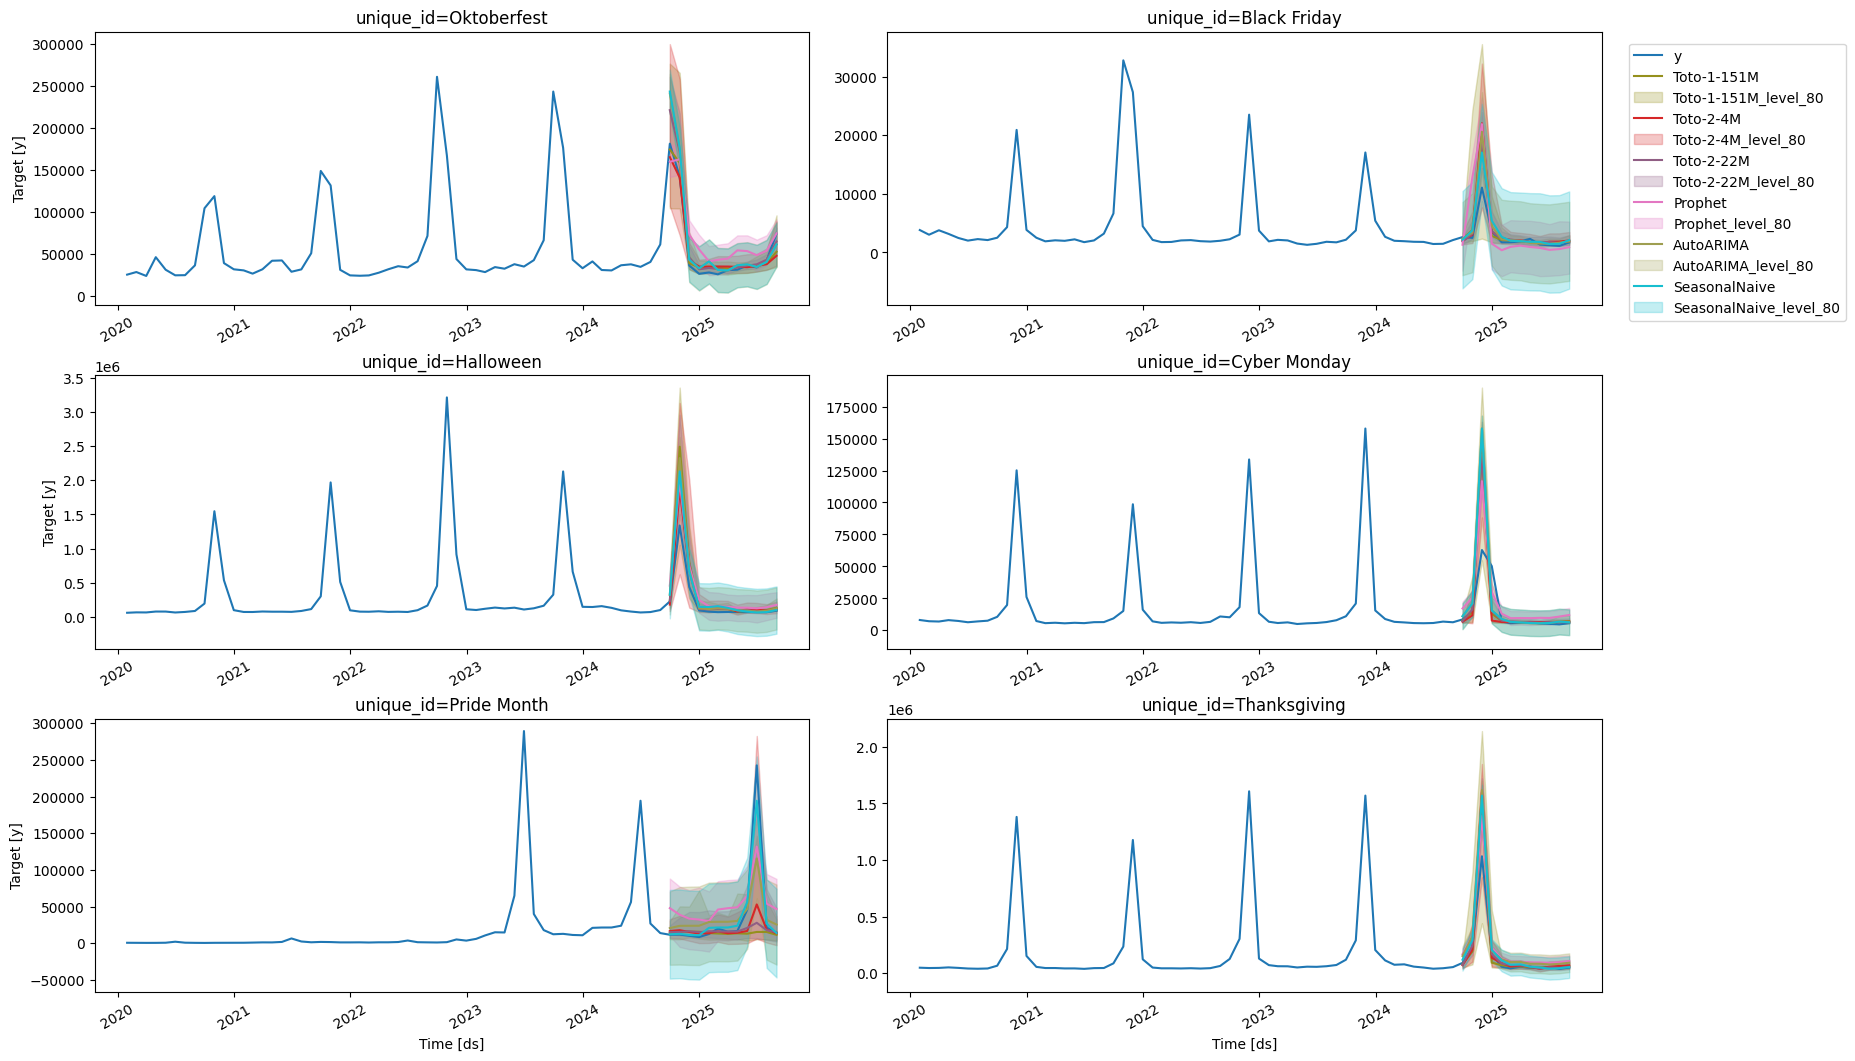

In [7]:
tcf.plot(df, cv_df.drop(columns=["cutoff", "y"]), level=[80])

In [8]:
cv_df.head()

,unique_id,ds,cutoff,y,Toto-1-151M,Toto-1-151M-lo-20,Toto-1-151M-hi-20,Toto-1-151M-lo-40,Toto-1-151M-hi-40,Toto-1-151M-lo-60,...,AutoARIMA-hi-80,SeasonalNaive,SeasonalNaive-lo-20,SeasonalNaive-lo-40,SeasonalNaive-lo-60,SeasonalNaive-lo-80,SeasonalNaive-hi-20,SeasonalNaive-hi-40,SeasonalNaive-hi-60,SeasonalNaive-hi-80
0,Black Friday,2024-09-30,2024-08-31,2607,2283.181641,2095.403809,2407.186035,1977.569336,2541.843750,1865.353516,...,8584.679688,2160.0,518.105774,-1238.539673,-3294.386475,-6145.491211,3801.894287,5558.539551,7614.386719,10465.491211
1,Black Friday,2024-10-31,2024-08-31,2470,3818.743164,3250.046631,4433.304688,2582.338867,6564.485352,2203.843994,...,10106.004883,3746.0,2104.105713,347.460358,-1708.386597,-4559.491211,5387.894043,7144.539551,9200.386719,12051.491211
2,Black Friday,2024-11-30,2024-08-31,11058,18899.695312,15117.933594,21524.937500,11459.410156,24256.669922,7209.637207,...,27347.144531,17053.0,15411.105469,13654.459961,11598.613281,8747.508789,18694.894531,20451.539062,22507.386719,25358.490234
3,Black Friday,2024-12-31,2024-08-31,3548,2831.026367,2498.486572,3178.491455,2320.758789,3893.141113,2095.536133,...,11227.885742,5407.0,3765.105713,2008.460327,-47.386593,-2898.491211,7048.894043,8805.540039,10861.386719,13712.491211
4,Black Friday,2025-01-31,2024-08-31,1724,2105.906250,1962.734375,2244.029785,1869.228027,2564.659424,1767.263428,...,8978.124023,2656.0,1014.105774,-742.539673,-2798.386475,-5649.491211,4297.894043,6054.539551,8110.386719,10961.491211


## Evaluation

In [9]:
from functools import partial

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mase, scaled_crps

In [10]:
eval_df = evaluate(
    cv_df.drop(columns=["cutoff"]),
    train_df=df.query("ds <= '2024-08-31'"),
    metrics=[partial(mase, seasonality=12), scaled_crps],
    level=level,
)
eval_df.groupby("metric").mean(numeric_only=True).T.sort_values(
    by="scaled_crps"
).round(3)

metric,mase,scaled_crps
Toto-2-4M,1.565,0.333
Toto-1-151M,1.533,0.353
Toto-2-22M,1.499,0.362
SeasonalNaive,1.576,0.521
Prophet,2.168,0.559
AutoARIMA,1.897,0.565
